# Install libraries

In [2]:
%pip install gplearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 775.1 kB/s eta 0:00:000:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 26.3 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.1 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


# Import libraries

In [3]:
import pandas as pd
import numpy as np
import os
import sys
project_root = os.path.abspath('/kaggle/input/datasets/phmhuyphongp/modules-vn')
if project_root not in sys.path:
    sys.path.append(project_root)

import src.evaluation as ev
import src.significance_test as st

# Read Data

These files must contain the `pred_score` and `date` columns to proceed.


In [4]:
# Expanding window, i.e. more data when training
df_ndcg_ex = pd.read_parquet('/kaggle/input/datasets/phmhuyphongp/nkkh-predicted-df/ndcg_expanding.parquet')
df_ndcg_ex['date'] = pd.to_datetime(df_ndcg_ex['date'])
# Fixed rolling window
df_ndcg = pd.read_parquet('/kaggle/input/datasets/phmhuyphongp/nkkh-predicted-df/ndcg.parquet')
df_ndcg['date'] = pd.to_datetime(df_ndcg['date'])

df_lstm = pd.read_parquet('/kaggle/input/datasets/phmhuyphongp/nkkh-predicted-df/lstm.parquet')
df_lstm['date'] = pd.to_datetime(df_lstm['date'])

df_mse = pd.read_parquet('/kaggle/input/datasets/phmhuyphongp/nkkh-predicted-df/mse.parquet')
df_mse['date'] = pd.to_datetime(df_mse['date'])

df_linear = pd.read_parquet('/kaggle/input/datasets/phmhuyphongp/nkkh-predicted-df/linear.parquet')
df_linear['date'] = pd.to_datetime(df_linear['date'])
#You the list can go on if needed

# Running testes

`p_naive` treats each day as independent, while `p_value` accounts for serial dependence by resampling blocks of consecutive days. The two differ substantially, indicating that the daily deltas are strongly autocorrelated. We use block = 21 because the target is the return over the next 21 trading days (scaled by the past 63-day volatility), so the targets of adjacent days share 20 of 21 days of price movement. `p_holm` is the Holm-adjusted p-value, which controls the family-wise error rate across the several models compared within each table.

Map DataFrames with their names

In [5]:
dfs = {
    'Expanding XGBoost-LambdaRank':df_ndcg_ex,
    'Rolling XGBoost-LambdaRank': df_ndcg,
    'Rolling XGBoost Regressor': df_mse,
    'Rolling LSTM': df_lstm,
    'Rolling Linear Regression': df_linear,
}

## Autocorrelation check: how should the significance tests handle dependence between days?

The significance tests are run on daily deltas (the model's top-k average target minus a benchmark's, per day). If these deltas are dependent across days, treating each day as independent (`block=1`) overstates the evidence. So I check their autocorrelation first, to decide between two options:

- treat each day as independent (`block=1`), or
- resample blocks of consecutive days (`block>1`).

**Daily deltas (`plot_autocorr`, 60 lags).** The target is the return over the next 21 trading days divided by the past 63-day volatility, so the targets of adjacent days share 20 of 21 days of price movement. The autocorrelation is high at short lags (about 0.6 to 0.87 at lag 1) and falls to about zero by lag 21, which matches this overlap. The daily tests therefore use `block=21`. A larger block (e.g. `block=42`) can be used as a sensitivity check.

**Thinned deltas (`step=21`).** Keeping every 21st date removes the overlap between targets. The autocorrelation of the thinned series (71 points) is mostly inside the noise band, so no clear leftover dependence is detectable and the thinned tests use `block=1`, with `block=3` as a sensitivity check. With only 71 points, the check can detect strong dependence only, so this means "not detectable", not "absent". Results depend on the starting offset (0 to

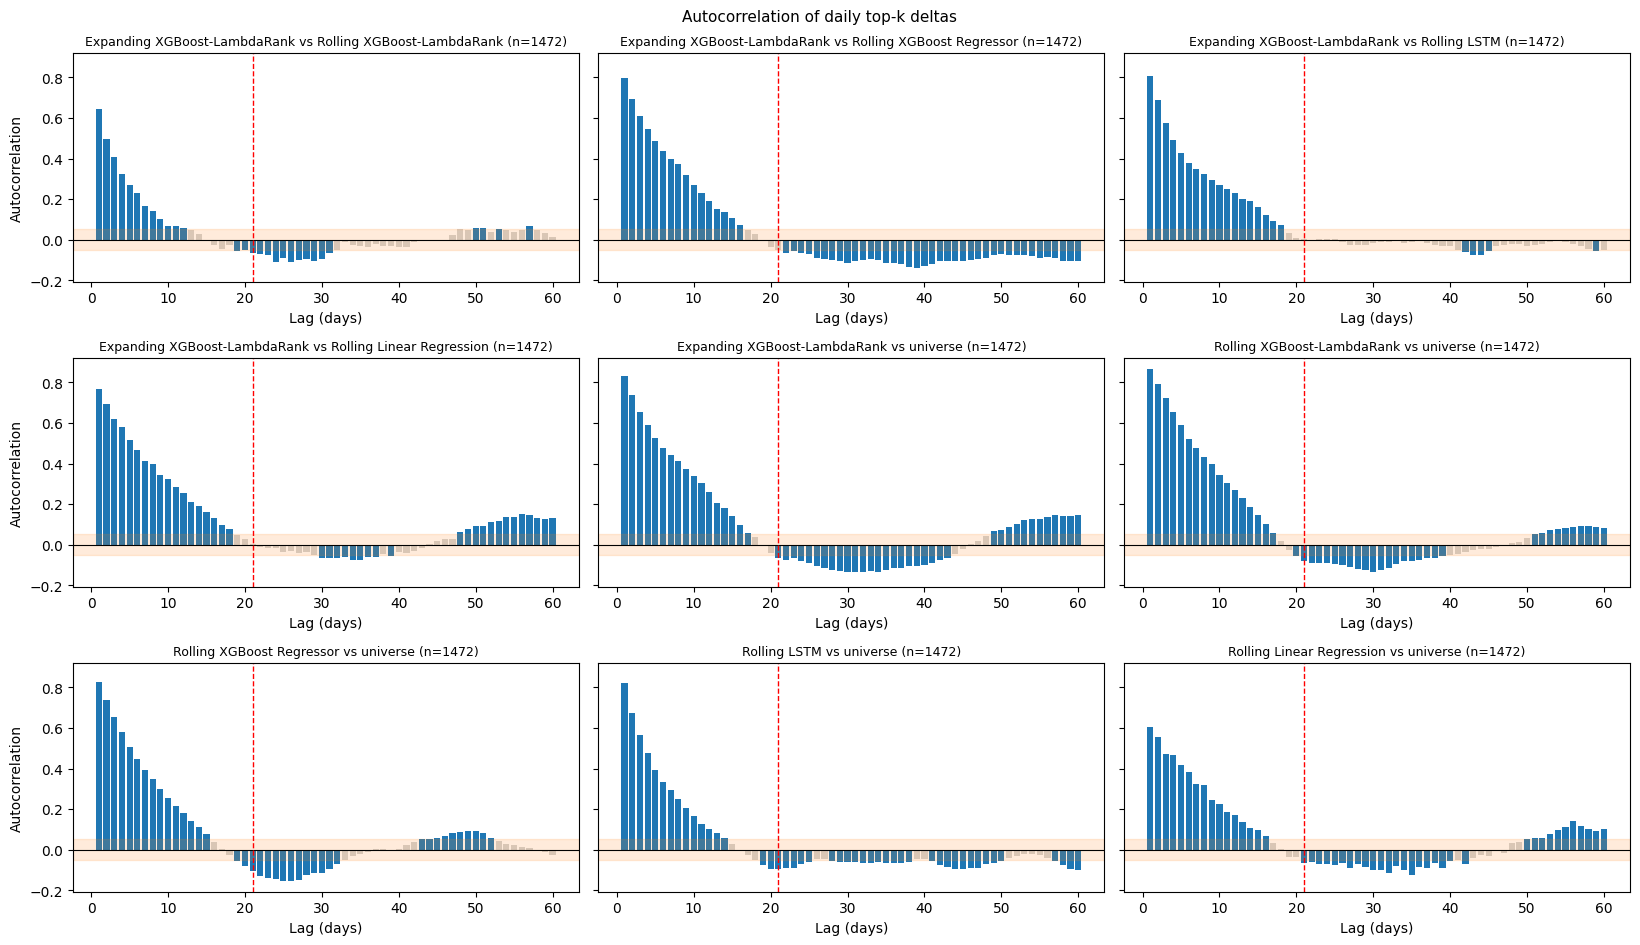

                                                comparison    n  band  suggested_block
Expanding XGBoost-LambdaRank vs Rolling XGBoost-LambdaRank 1472 0.051               21
 Expanding XGBoost-LambdaRank vs Rolling XGBoost Regressor 1472 0.051               21
              Expanding XGBoost-LambdaRank vs Rolling LSTM 1472 0.051               21
 Expanding XGBoost-LambdaRank vs Rolling Linear Regression 1472 0.051               21
                  Expanding XGBoost-LambdaRank vs universe 1472 0.051               21
                    Rolling XGBoost-LambdaRank vs universe 1472 0.051               40
                     Rolling XGBoost Regressor vs universe 1472 0.051               21
                                  Rolling LSTM vs universe 1472 0.051               21
                     Rolling Linear Regression vs universe 1472 0.051               21
(orange band = noise range; with few points it is wide, so "inside the band" means "not detectable", not "absent". Use the largest

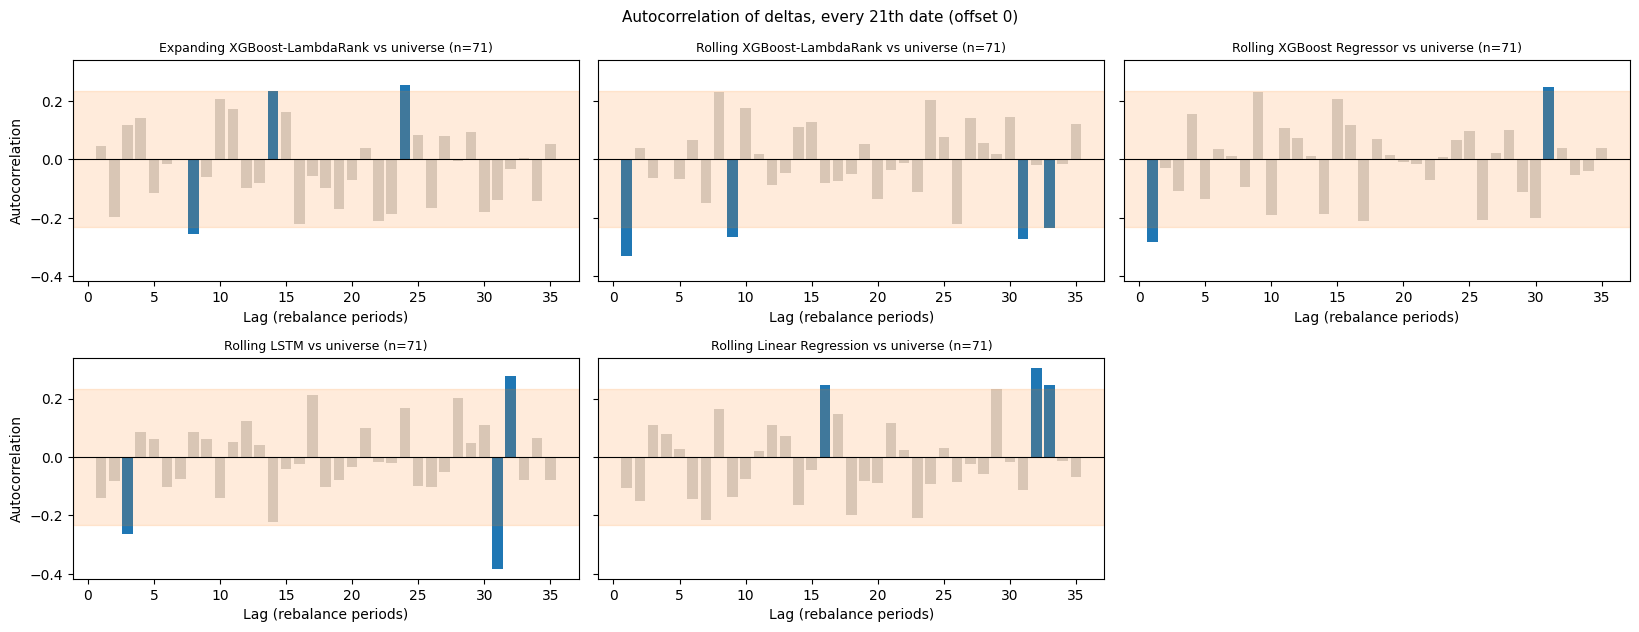

                              comparison  n  band  suggested_block
Expanding XGBoost-LambdaRank vs universe 71 0.233                1
  Rolling XGBoost-LambdaRank vs universe 71 0.233                2
   Rolling XGBoost Regressor vs universe 71 0.233                2
                Rolling LSTM vs universe 71 0.233                4
   Rolling Linear Regression vs universe 71 0.233                1
(orange band = noise range; with few points it is wide, so "inside the band" means "not detectable", not "absent". Use the largest suggested block, or a bit more.)


,comparison,n,band,suggested_block
0,Expanding XGBoost-LambdaRank vs universe,71,0.233,1
1,Rolling XGBoost-LambdaRank vs universe,71,0.233,2
2,Rolling XGBoost Regressor vs universe,71,0.233,2
3,Rolling LSTM vs universe,71,0.233,4
4,Rolling Linear Regression vs universe,71,0.233,1


In [6]:
st.plot_autocorr(dfs, 'Expanding XGBoost-LambdaRank', mode='both')          # daily deltas, 60 lags
st.plot_autocorr(dfs, 'Expanding XGBoost-LambdaRank', mode='universe', step=21, offset=0)  # leftover dependence after thinning

## Significance test between Expanding XGBoost-LambdaRank against other rolling model


=== Expanding XGBoost-LambdaRank vs other models (delta = Expanding XGBoost-LambdaRank - other; >0 => Expanding XGBoost-LambdaRank better) ===
                                                comparison  mean_delta  n_days  block  p_value  p_naive   ci_lo  ci_hi  p_holm  significant  significant_holm
Expanding XGBoost-LambdaRank vs Rolling XGBoost-LambdaRank      0.1310    1472     21   0.4984   0.1156 -0.2671 0.5308  0.4984        False             False
 Expanding XGBoost-LambdaRank vs Rolling XGBoost Regressor      0.7227    1472     21   0.0620   0.0001 -0.0347 1.5194  0.2480        False             False
              Expanding XGBoost-LambdaRank vs Rolling LSTM      0.5503    1472     21   0.1413   0.0001 -0.1985 1.3306  0.4239        False             False
 Expanding XGBoost-LambdaRank vs Rolling Linear Regression      0.5631    1472     21   0.2014   0.0001 -0.3139 1.4511  0.4239        False             False


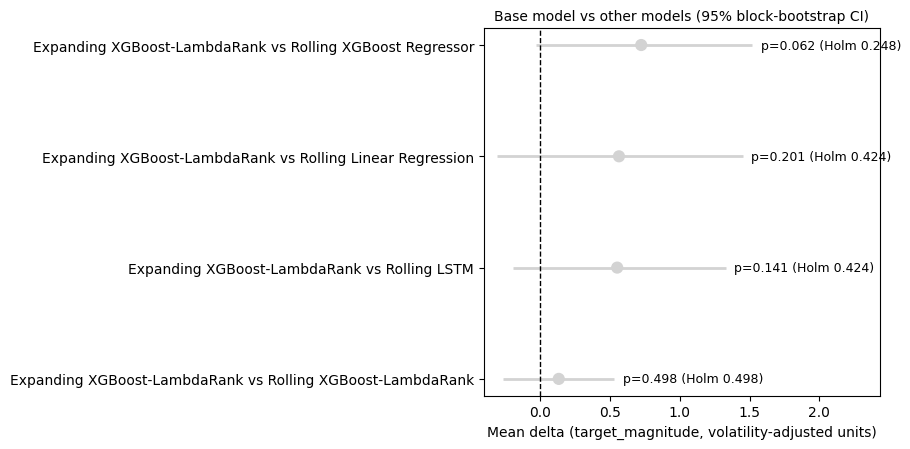

In [7]:


results_1 = st.run_analysis(dfs, k=20, base_model = 'Expanding XGBoost-LambdaRank',block = 21, mode = 'base')

## Significance test between model and the whole universe


=== each model top-k vs universe (delta = top-k - universe; >0 => beats universe) ===
                              comparison  mean_delta  n_days  block  p_value  p_naive   ci_lo  ci_hi  p_holm  significant  significant_holm
Expanding XGBoost-LambdaRank vs universe      1.1452      71     21   0.1203   0.0246  0.2049 2.0664  0.6014        False             False
  Rolling XGBoost-LambdaRank vs universe      0.9638      71     21   0.1203   0.0884  0.2436 1.4844  0.6014        False             False
   Rolling XGBoost Regressor vs universe      0.0638      71     21   1.0000   0.8904 -0.4864 0.7515  1.0000        False             False
                Rolling LSTM vs universe      0.3985      71     21   0.2476   0.3274  0.0165 0.6446  0.7427        False             False
   Rolling Linear Regression vs universe     -0.1175      71     21   0.8713   0.7847 -0.9134 0.3208  1.0000        False             False


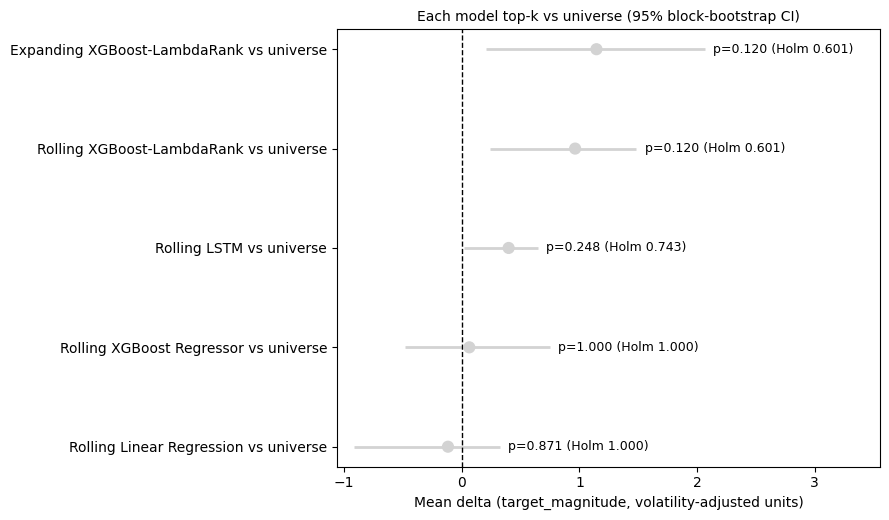

In [8]:


results_2 = st.run_analysis(dfs, k=20, base_model = 'Expanding XGBoost-LambdaRank',block = 21,step=21, mode = 'universe')